<a href="https://colab.research.google.com/github/Seribii1o1/NYC-311-Service-Request-Analysis/blob/main/NYC_311_Service_Request_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Christina Maroun

06/18/2026

Using a 2024 NYC-Brooklyn 311 service request dataset, I produced an EDA, visualizations, SQL queries, and insight brief/reflection.

**Exploratory Data Analysis (EDA)**

In [ ]:
# import modules
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# upload dataset file
from google.colab import files
uploaded=files.upload()

Saving brooklyn_2024-01-01_2025-01-01.parquet to brooklyn_2024-01-01_2025-01-01 (1).parquet


In [ ]:
# Load file and print out first 5 rows of data
df=pd.read_parquet('brooklyn_2024-01-01_2025-01-01.parquet')
df.head()

,unique_key,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,latitude,longitude,city,response_hours
0,63573950,2024-12-31 23:59:38,2025-01-01 00:26:35,Illegal Fireworks,N/A,BROOKLYN,NYPD,New York City Police Department,Closed,11218,40.640914779776715,-73.97364216306418,None,0.449167
1,63581093,2024-12-31 23:59:32,2025-01-01 00:18:51,Noise - Residential,Loud Music/Party,BROOKLYN,NYPD,New York City Police Department,Closed,11221,40.688334599490894,-73.93014442097454,BROOKLYN,0.321944
2,63580924,2024-12-31 23:59:21,2025-01-01 00:42:47,Noise - Residential,Loud Music/Party,BROOKLYN,NYPD,New York City Police Department,Closed,11230,40.6347449187686,-73.96493632865035,BROOKLYN,0.723889
3,63575575,2024-12-31 23:58:34,2025-01-01 00:05:49,Noise - Residential,Banging/Pounding,BROOKLYN,NYPD,New York City Police Department,Closed,11211,40.71120965026345,-73.95897331500413,BROOKLYN,0.120833
4,63572345,2024-12-31 23:58:21,2025-01-01 00:06:15,Noise - House of Worship,Loud Music/Party,BROOKLYN,NYPD,New York City Police Department,Closed,11233,40.677589846078284,-73.91914887353346,BROOKLYN,0.131667


In [ ]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(1045072, 14)


In [ ]:
# Drop unique_key column
df.drop('unique_key', axis=1, inplace=True)
df.head()

,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,latitude,longitude,city,response_hours
0,2024-12-31 23:59:38,2025-01-01 00:26:35,Illegal Fireworks,N/A,BROOKLYN,NYPD,New York City Police Department,Closed,11218,40.640914779776715,-73.97364216306418,None,0.449167
1,2024-12-31 23:59:32,2025-01-01 00:18:51,Noise - Residential,Loud Music/Party,BROOKLYN,NYPD,New York City Police Department,Closed,11221,40.688334599490894,-73.93014442097454,BROOKLYN,0.321944
2,2024-12-31 23:59:21,2025-01-01 00:42:47,Noise - Residential,Loud Music/Party,BROOKLYN,NYPD,New York City Police Department,Closed,11230,40.6347449187686,-73.96493632865035,BROOKLYN,0.723889
3,2024-12-31 23:58:34,2025-01-01 00:05:49,Noise - Residential,Banging/Pounding,BROOKLYN,NYPD,New York City Police Department,Closed,11211,40.71120965026345,-73.95897331500413,BROOKLYN,0.120833
4,2024-12-31 23:58:21,2025-01-01 00:06:15,Noise - House of Worship,Loud Music/Party,BROOKLYN,NYPD,New York City Police Department,Closed,11233,40.677589846078284,-73.91914887353346,BROOKLYN,0.131667


In [ ]:
# Print out general information on this dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1045072 entries, 0 to 1045071
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   created_date    1045072 non-null  datetime64[us]
 1   closed_date     1030027 non-null  datetime64[us]
 2   complaint_type  1045072 non-null  object        
 3   descriptor      1038478 non-null  object        
 4   borough         1045072 non-null  object        
 5   agency          1045072 non-null  object        
 6   agency_name     1045072 non-null  object        
 7   status          1045072 non-null  object        
 8   incident_zip    1038887 non-null  object        
 9   latitude        1033123 non-null  object        
 10  longitude       1033123 non-null  object        
 11  city            1003772 non-null  object        
 12  response_hours  1030027 non-null  float64       
dtypes: datetime64[us](2), float64(1), object(10)
memory usage: 103.7+ MB


In [ ]:
# Summary statistics response_hours
df['response_hours'].describe()

,response_hours
count,1.030027e+06
mean,3.160896e+02
std,1.146238e+03
min,-2.640000e+02
25%,9.019444e-01
50%,6.295278e+00
75%,9.116194e+01
max,2.061427e+04


I will investigate why there is negative response hours.

In [ ]:
num_negative_response_hours = df[df['response_hours'] < 0].shape[0]
print(f"Number of rows with negative response_hours: {num_negative_response_hours}")

Number of rows with negative response_hours: 78


In [ ]:
df_negative_response_hours = df[df['response_hours'] < 0]
display(df_negative_response_hours)

,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,latitude,longitude,city,response_hours
3414,2024-12-30 15:34:00,2024-12-29 15:33:00,Street Light Condition,Street Light Out,BROOKLYN,DOT,Department of Transportation,Pending,11217,40.677679573958926,-73.97959791851258,BROOKLYN,-24.016667
3419,2024-12-30 15:31:00,2024-12-26 15:30:00,Street Light Condition,Street Light Out,BROOKLYN,DOT,Department of Transportation,Pending,11217,40.67704835183575,-73.98003073692966,BROOKLYN,-96.016667
3430,2024-12-30 15:28:00,2024-12-29 15:27:00,Street Light Condition,Street Light Out,BROOKLYN,DOT,Department of Transportation,Pending,11217,40.67704835183575,-73.98003073692966,BROOKLYN,-24.016667
3466,2024-12-30 15:18:00,2024-12-29 15:16:00,Street Light Condition,Street Light Out,BROOKLYN,DOT,Department of Transportation,Pending,11215,40.675777667039114,-73.98088914125927,BROOKLYN,-24.033333
4709,2024-12-30 08:33:00,2024-12-29 08:32:00,Street Light Condition,Street Light Out,BROOKLYN,DOT,Department of Transportation,Pending,11206,40.69987389854862,-73.94042152086969,BROOKLYN,-24.016667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035421,2024-12-30 15:28:00,2024-12-29 15:27:00,Street Light Condition,Street Light Out,BROOKLYN,DOT,Department of Transportation,Pending,11217,40.67704835183575,-73.98003073692966,BROOKLYN,-24.016667
1036946,2024-12-30 15:31:00,2024-12-26 15:30:00,Street Light Condition,Street Light Out,BROOKLYN,DOT,Department of Transportation,Pending,11217,40.67704835183575,-73.98003073692966,BROOKLYN,-96.016667
1037266,2024-12-30 08:33:00,2024-12-29 08:32:00,Street Light Condition,Street Light Out,BROOKLYN,DOT,Department of Transportation,Pending,11206,40.69987389854862,-73.94042152086969,BROOKLYN,-24.016667
1038156,2024-12-30 15:34:00,2024-12-29 15:33:00,Street Light Condition,Street Light Out,BROOKLYN,DOT,Department of Transportation,Pending,11217,40.677679573958926,-73.97959791851258,BROOKLYN,-24.016667


I will investigate if these requests are all pending status.

In [ ]:
print(df_negative_response_hours['status'].unique())

['Pending' 'Closed']


They are not all pending so I will see how many are closed.

In [ ]:
status_counts = df_negative_response_hours['status'].value_counts()
print(status_counts)

status
Pending    56
Closed     22
Name: count, dtype: int64


Based on the inspection, these 78 rows contain logically inconsistent dates or belong to 'Pending' cases with invalid closed dates. I will remove them to maintain data integrity.

In [ ]:
# Remove the 78 rows with negative response_hours
df = df[~(df['response_hours'] < 0)]

# Verify removal
print(f"New number of rows: {df.shape[0]}")
print(f"Remaining negative values: {(df['response_hours'] < 0).sum()}")

New number of rows: 1044994
Remaining negative values: 0


In [ ]:
# Filter for incident_zips that do not start with '112'
# Drop duplicates and NaNs to get the unique list
non_112_zips = df[df['incident_zip'].notnull() & ~df['incident_zip'].astype(str).str.startswith('112')]['incident_zip'].unique()

print(f"Number of unique incident_zips not starting with 112: {len(non_112_zips)}")
print("Unique zip codes:")
print(non_112_zips)

Number of unique incident_zips not starting with 112: 3
Unique zip codes:
['11416' '11385' '11421']


I found zipcodes that are not Brooklyn. I will investigate more.

In [ ]:
df[df['incident_zip'].isin(non_112_zips)]['incident_zip'].value_counts()

,count
incident_zip,
11385,6
11416,1
11421,1


In [ ]:
# Display the rows with incident_zips that do not start with 112
not_brooklyn_rows = df[df['incident_zip'].isin(non_112_zips)]
display(not_brooklyn_rows)

,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,latitude,longitude,city,response_hours
73447,2024-01-23 12:52:58,2024-01-30 12:11:19,Dead Animal,Cat,BROOKLYN,DSNY,Department of Sanitation,Closed,11416,40.68212831156801,-73.86499254252409,None,167.305833
162602,2024-02-27 07:24:09,2024-02-27 07:24:09,Rodent,Rat Sighting,BROOKLYN,DOHMH,Department of Health and Mental Hygiene,Closed,11385,None,None,BROOKLYN,0.000000
165764,2024-02-27 07:12:07,2024-02-27 23:47:57,Dirty Condition,Trash,BROOKLYN,DSNY,Department of Sanitation,Closed,11385,None,None,None,16.597222
430410,2024-06-05 17:40:31,2024-06-06 14:03:22,Street Sweeping Complaint,Inadequate Sweeping,BROOKLYN,DSNY,Department of Sanitation,Closed,11385,None,None,None,20.380833
672181,2024-08-27 08:43:00,2024-08-28 09:28:00,Street Light Condition,Lamppost Leaning,BROOKLYN,DOT,Department of Transportation,Closed,11421,40.68682972322479,-73.86701666324849,BROOKLYN,24.750000
788717,2024-10-06 15:02:02,2024-10-06 15:53:40,Blocked Driveway,No Access,BROOKLYN,NYPD,New York City Police Department,Closed,11385,None,None,None,0.860556
805444,2024-10-12 01:28:37,2024-10-12 01:48:39,Noise - Commercial,Loud Music/Party,BROOKLYN,NYPD,New York City Police Department,Closed,11385,None,None,None,0.333889
862024,2024-10-30 11:32:41,2024-10-30 11:32:41,Rodent,Rat Sighting,BROOKLYN,DOHMH,Department of Health and Mental Hygiene,Closed,11385,None,None,BROOKLYN,0.000000


These eight requests do not have brooklyn zipcodes and will be dropped.

In [ ]:
# Remove the 8 rows with non-Brooklyn zip codes
df = df[~df['incident_zip'].isin(non_112_zips)]

# Verify removal
print(f"Updated number of rows: {df.shape[0]}")

Updated number of rows: 1044986


In [ ]:
# Check unique values for status
print("Unique Statuses:")
print(df['status'].unique())

Unique Statuses:
['Closed' 'Open' 'Started' 'In Progress' 'Assigned' 'Pending'
 'Unspecified']


In [ ]:
# Check unique 'status' for rows where 'closed_date' is not null
unique_statuses_closed = df[df['closed_date'].notnull()]['status'].unique()
print("Unique statuses for rows with a non-null closed_date:")
print(unique_statuses_closed)

Unique statuses for rows with a non-null closed_date:
['Closed' 'Assigned' 'Open' 'Unspecified' 'Started' 'Pending']


In [ ]:
# Display rows where closed_date is not null but status is not 'Closed'
closed_date_not_closed_status = df[df['closed_date'].notnull() & (df['status'] != 'Closed')]
display(closed_date_not_closed_status)

,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,latitude,longitude,city,response_hours
2893,2024-12-30 19:20:38,2025-10-29 00:00:00,Building/Use,Illegal Conversion Of Residential Building/Space,BROOKLYN,DOB,Department of Buildings,Assigned,11226,40.63779704760559,-73.95666563198222,BROOKLYN,7252.656111
4408,2024-12-30 10:16:41,2024-12-30 10:16:41,General Construction/Plumbing,Curb Cut/Driveway/Carport - Illegal,BROOKLYN,DOB,Department of Buildings,Open,11234,40.63297539214463,-73.92617800641766,BROOKLYN,0.000000
23443,2024-12-22 17:54:07,2024-12-22 17:54:07,Building/Use,Illegal. Commercial Use In Resident Zone,BROOKLYN,DOB,Department of Buildings,Open,11229,40.59845330935582,-73.9501878189173,BROOKLYN,0.000000
25820,2024-12-21 23:52:25,2024-12-21 23:52:25,Building/Use,Zoning - Non-Conforming/Illegal Vehicle Storage,BROOKLYN,DOB,Department of Buildings,Open,11234,40.62388599249968,-73.91613392668832,BROOKLYN,0.000000
31083,2024-12-20 09:31:00,2024-12-24 18:45:00,Traffic Signal Condition,Junction Box,BROOKLYN,DOT,Department of Transportation,Assigned,11223,40.59688292383929,-73.97408444865714,BROOKLYN,105.233333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1031740,2024-01-16 14:07:00,2024-01-18 11:40:00,Traffic Signal Condition,LED Lense,BROOKLYN,DOT,Department of Transportation,Assigned,None,None,None,None,45.550000
1036433,2024-12-30 10:16:41,2024-12-30 10:16:41,General Construction/Plumbing,Curb Cut/Driveway/Carport - Illegal,BROOKLYN,DOB,Department of Buildings,Open,11234,40.63297539214463,-73.92617800641766,BROOKLYN,0.000000
1038209,2024-12-30 19:20:38,2025-10-29 00:00:00,Building/Use,Illegal Conversion Of Residential Building/Space,BROOKLYN,DOB,Department of Buildings,Assigned,11226,40.63779704760559,-73.95666563198222,BROOKLYN,7252.656111
1041505,2024-02-22 16:09:21,2024-02-24 00:00:00,Plumbing,Failure To Retain Water/Improper Drainage- (LL...,BROOKLYN,DOB,Department of Buildings,Assigned,11209,40.63617317408419,-74.03173885021056,BROOKLYN,31.844167


Found 569 requests where a closed_date exists but the status is still something else (like 'Assigned' or 'Open'). Since the closed_date is filled with precision, I will update the status to Closed.

In [ ]:
# Update status to 'Closed' where closed_date is not null
df.loc[df['closed_date'].notnull(), 'status'] = 'Closed'

# Print the updated count for all unique statuses
status_distribution = df['status'].value_counts()
print("Updated status distribution:")
print(status_distribution)

Updated status distribution:
status
Closed         1033887
In Progress       8418
Open              1924
Assigned           267
Started            259
Pending            229
Unspecified          2
Name: count, dtype: int64


In [ ]:
# Display the 2 rows with 'Unspecified' status
unspecified_status_rows = df[df['status'] == 'Unspecified']
display(unspecified_status_rows)

,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,latitude,longitude,city,response_hours
757560,2024-09-24 13:40:54,NaT,For Hire Vehicle Report,Car Service Company Report,BROOKLYN,TLC,Taxi and Limousine Commission,Unspecified,11234,40.62807615796354,-73.91459757028082,BROOKLYN,NaN
922301,2024-11-19 06:15:20,NaT,For Hire Vehicle Complaint,Driver Complaint - Non Passenger,BROOKLYN,TLC,Taxi and Limousine Commission,Unspecified,11234,40.64328850742449,-73.8761767792267,None,NaN


In [ ]:
# Update 'Unspecified' status to 'Open'
df.loc[df['status'] == 'Unspecified', 'status'] = 'Open'

# Verify the change
print("Updated status distribution:")
print(df['status'].value_counts())

# Check the specific rows previously identified
display(df.loc[unspecified_status_rows.index])

Updated status distribution:
status
Closed         1033887
In Progress       8418
Open              1926
Assigned           267
Started            259
Pending            229
Name: count, dtype: int64


,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,latitude,longitude,city,response_hours
757560,2024-09-24 13:40:54,NaT,For Hire Vehicle Report,Car Service Company Report,BROOKLYN,TLC,Taxi and Limousine Commission,Open,11234,40.62807615796354,-73.91459757028082,BROOKLYN,NaN
922301,2024-11-19 06:15:20,NaT,For Hire Vehicle Complaint,Driver Complaint - Non Passenger,BROOKLYN,TLC,Taxi and Limousine Commission,Open,11234,40.64328850742449,-73.8761767792267,None,NaN


In [ ]:
# Count rows where status is 'Closed' but closed_date is null
closed_missing_date_count = df[(df['status'] == 'Closed') & (df['closed_date'].isnull())].shape[0]
print(f"Number of rows with 'Closed' status but missing 'closed_date': {closed_missing_date_count}")

Number of rows with 'Closed' status but missing 'closed_date': 3946


There are 3946 requests with a missing closed_date time stamps. I am leaving this as is since there is a possiblity that it was manually marked closed but not time stamped.

In [ ]:
# 1. What are the top 10 most common complaint types (complaint_type) across the full dataset?
top_10_complaints = df['complaint_type'].value_counts().head(10)
print("Top 10 Most Common Complaint Types:")
print(top_10_complaints)

Top 10 Most Common Complaint Types:
complaint_type
Illegal Parking            193996
Noise - Residential         95601
HEAT/HOT WATER              71616
Blocked Driveway            64047
Noise - Street/Sidewalk     39376
UNSANITARY CONDITION        36658
Abandoned Vehicle           25454
Noise - Commercial          22817
Water System                20116
Dirty Condition             20003
Name: count, dtype: int64


/tmp/ipykernel_52668/339400481.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_complaints.values, y=top_10_complaints.index, palette='viridis')


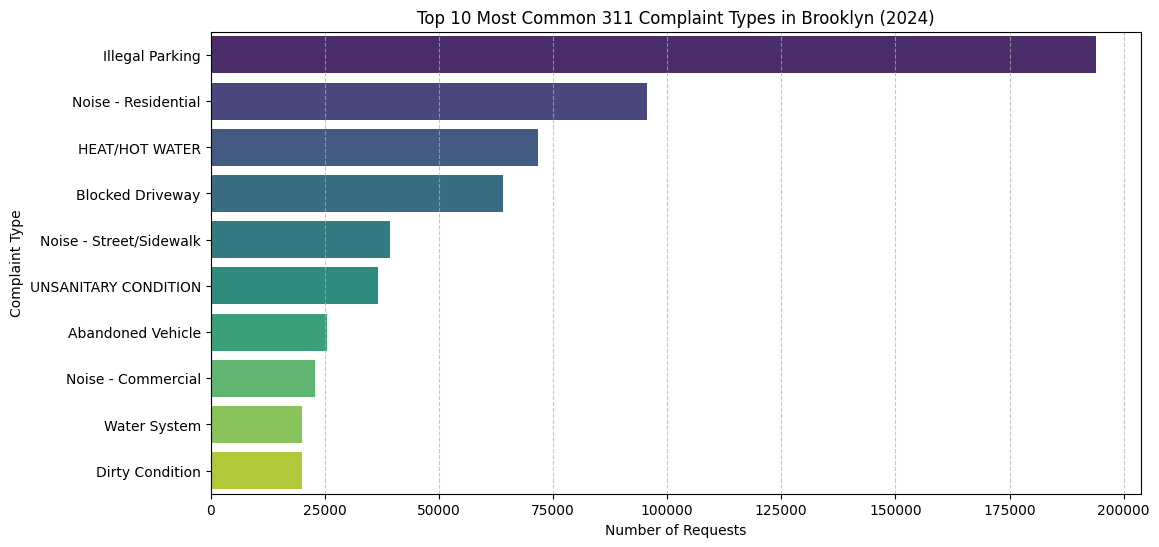

In [ ]:
import seaborn as sns

# Visualization: Top 10 Complaint Types
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_complaints.values, y=top_10_complaints.index, palette='viridis')
plt.title('Top 10 Most Common 311 Complaint Types in Brooklyn (2024)')
plt.xlabel('Number of Requests')
plt.ylabel('Complaint Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

This bar chart highlights the most frequent issues reported by residents, with Illegal Parking and Noise complaints dominating the service requests in Brooklyn. Illegal Parking is approximately 2x more frequent than Noise - Residential. Identifying these high-volume areas helps prioritize city resources and policy interventions.

In [ ]:
# 3. What is the average resolution time (in days) by agency? Use created_date and closed_date to calculate. Which agency resolves requests fastest — and which is slowest?

# Calculate resolution time in days
df['resolution_days'] = (df['closed_date'] - df['created_date']).dt.total_seconds() / (24 * 3600)

# Group by agency and calculate the mean resolution time
agency_resolution = df.groupby('agency')['resolution_days'].mean().sort_values()

print("Average Resolution Time (in days) by Agency:")
print(agency_resolution)

fastest_agency = agency_resolution.idxmin()
slowest_agency = agency_resolution.idxmax()

print(f"\nFastest Agency: {fastest_agency} ({agency_resolution.min():.2f} days)")
print(f"Slowest Agency: {slowest_agency} ({agency_resolution.max():.2f} days)")

Average Resolution Time (in days) by Agency:
agency
NYPD       0.084089
DEP        5.222375
DHS        5.523905
DSNY       5.811124
DOT       11.285926
HPD       14.644939
DCWP      14.829400
OTI       21.981369
DOHMH     48.244844
DOB       62.044195
EDC       68.272403
DOE       69.324350
TLC       94.105629
DPR      122.453540
Name: resolution_days, dtype: float64

Fastest Agency: NYPD (0.08 days)
Slowest Agency: DPR (122.45 days)


/tmp/ipykernel_52668/1087933495.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agency_resolution.values, y=agency_resolution.index, palette='magma')


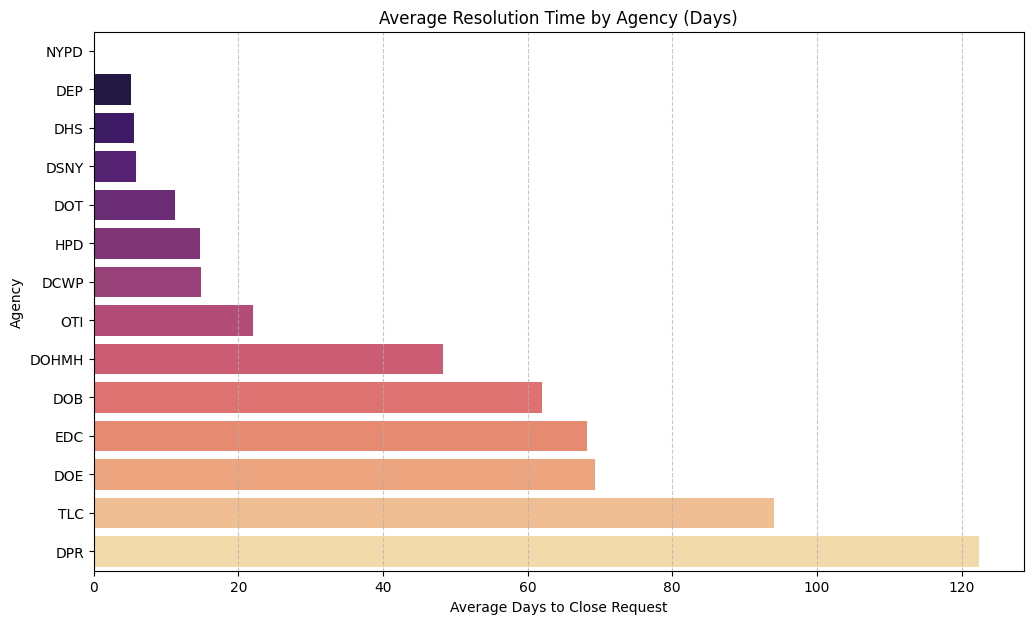

In [ ]:
# Visualization: Average Resolution Time by Agency
plt.figure(figsize=(12, 7))
sns.barplot(x=agency_resolution.values, y=agency_resolution.index, palette='magma')
plt.title('Average Resolution Time by Agency (Days)')
plt.xlabel('Average Days to Close Request')
plt.ylabel('Agency')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

The NYPD is the fastest agency, resolving requests in an average of approximately less than 2 hours. In contrast, the Department of Parks and Recreation is the slowest, taking an average of ~122 days to resolve requests.

**Bonus**

In [ ]:
# 4. Are there any complaint types that appear to be seasonal or concentrated in certain time periods? Use created_date to group by month. Show your evidence.

import plotly.graph_objects as go

# Extract month and year for grouping
df['month'] = df['created_date'].dt.month

# Prepare data
top_10_list = df['complaint_type'].value_counts().head(10).index.tolist()
heatmap_data = df[df['complaint_type'].isin(top_10_list)].groupby(['month', 'complaint_type']).size().reset_index(name='count')

# Pivot data for the heatmap
z_data = heatmap_data.pivot(index='complaint_type', columns='month', values='count').fillna(0)

# Create the heatmap using Graph Objects to bypass the px.density_heatmap bug
fig = go.Figure(data=go.Heatmap(
    z=z_data.values,
    x=z_data.columns,
    y=z_data.index,
    colorscale='Viridis',
    colorbar=dict(title='Requests'),
    hovertemplate='Month: %{x}<br>Complaint: %{y}<br>Count: %{z}<extra></extra>'
))

fig.update_layout(
    title='Interactive Heatmap: Top 10 311 Complaints by Month (2024)',
    xaxis=dict(title='Month', tickmode='linear', dtick=1),
    yaxis=dict(title='Complaint Type'),
    height=700,
    template='plotly_white'
)

fig.show()





Several complaint types show strong seasonality:

HEAT/HOT WATER: Peaks in December (24,474 requests) and January, few hundred during the summer months.

Noise - Street/Sidewalk: Concentrated in the warmer months, and hitting its lowest point in January (397 requests).

Illegal Parking & Noise - Residential: While common year-round, both show a significant spike in December. This could be due to roads needed to be plowed from snow. Residents could be staying in due to the cold weather and notice noise disturbances more.

Water System: Experienced a notable concentration in June and July, as well as a sharp increase in December.

These patterns suggest that environmental factors (temperature) and holiday periods significantly influence the volume of specific 311 service requests. Agencies can prepare for these seasonal/monthly requests such as hiring more staff during certain periods.

5. Identify at least one data quality issue in the dataset (hint: check incident_zip, closed_date, and status). How did you handle it?

I made earlier adjustments to ensure data quality. I got rid of 8 non-Brooklyn zipcodes. I got rid of 78 requests that had a closed_date before the created_date. I updated 569 requests to have closed status since they had a time stamp in the closed_date. I changed two unspecified requests status to open since they did not have a closed_date.

**Extra Visualizations**

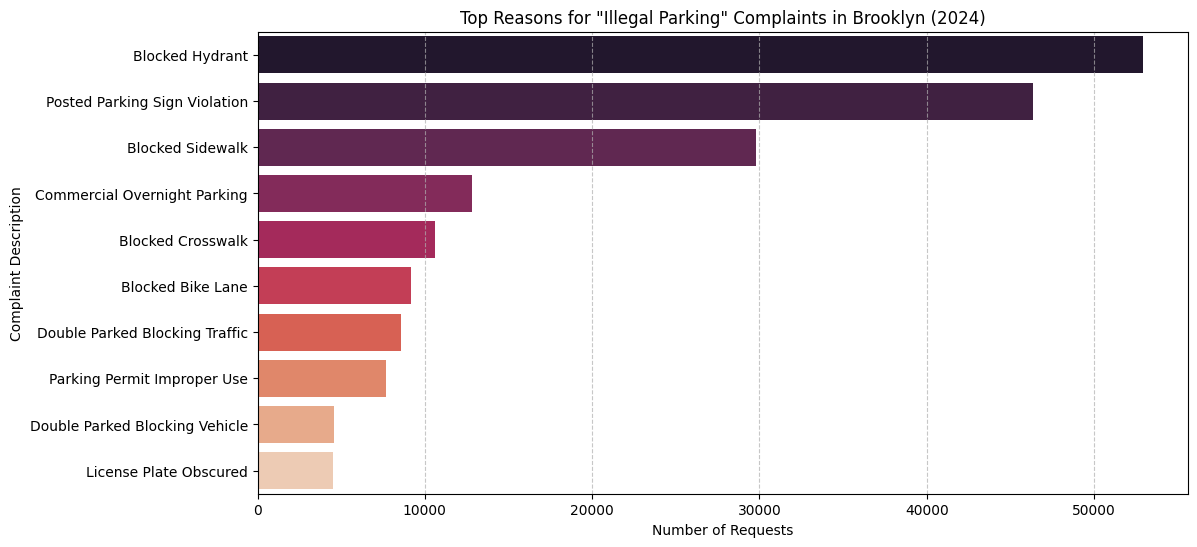

In [ ]:
# Ensure the dataframe is available and filter for Illegal Parking
illegal_parking_df = df[df['complaint_type'] == 'Illegal Parking']

# Analyze the top reasons (descriptors) for these complaints
parking_descriptors = illegal_parking_df['descriptor'].value_counts().head(10)

# Visualization: Specific reasons for Illegal Parking
plt.figure(figsize=(12, 6))
sns.barplot(x=parking_descriptors.values, y=parking_descriptors.index, hue=parking_descriptors.index, palette='rocket', legend=False)
plt.title('Top Reasons for "Illegal Parking" Complaints in Brooklyn (2024)')
plt.xlabel('Number of Requests')
plt.ylabel('Complaint Description')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

The top reasons for illegal parking compliants in Brooklyn are blocked hydrant, posted parking sign violation, and blocked sidewalk.

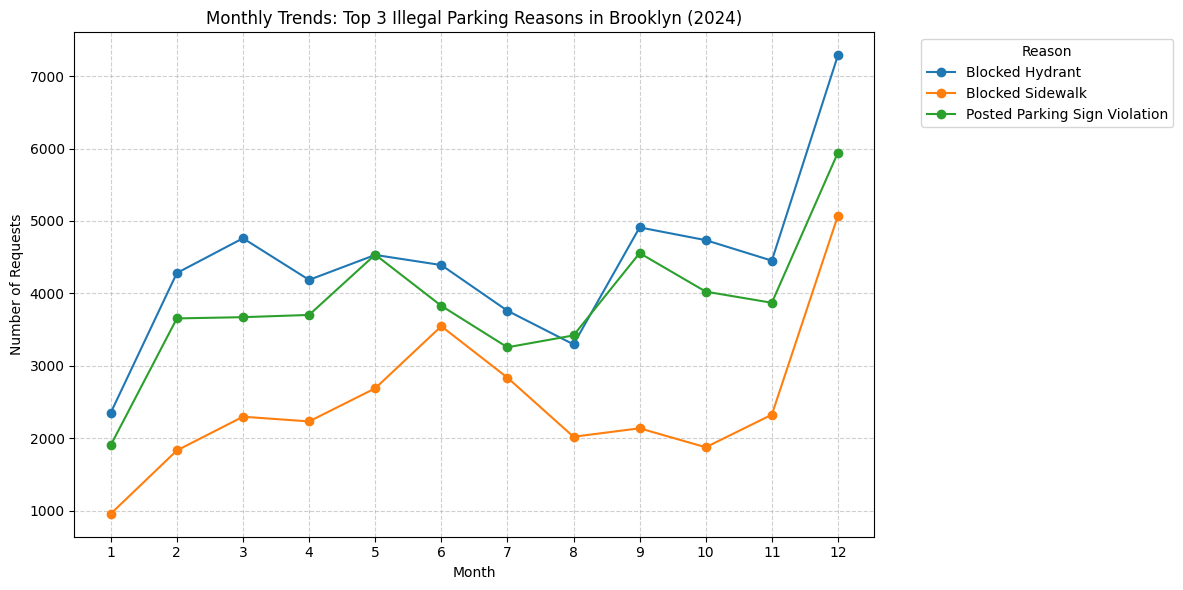

In [ ]:
# Define the top 3 reasons provided
top_reasons = ['Blocked Hydrant', 'Posted Parking Sign Violation', 'Blocked Sidewalk']

# Filter illegal_parking_df for these specific descriptors
top_parking_df = illegal_parking_df[illegal_parking_df['descriptor'].isin(top_reasons)]

# Group by month and descriptor
monthly_parking_trends = top_parking_df.groupby(['month', 'descriptor']).size().unstack(fill_value=0)

# Plotting the trends over months
plt.figure(figsize=(12, 6))
monthly_parking_trends.plot(ax=plt.gca(), marker='o')
plt.title('Monthly Trends: Top 3 Illegal Parking Reasons in Brooklyn (2024)')
plt.xlabel('Month')
plt.ylabel('Number of Requests')
plt.xticks(range(1, 13))
plt.legend(title='Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

December still shows the highest for the three major illegal parking reasons! This is something to investigate more. Could be because of snow piles reducing parking spaces and residents being home more often to report these issues.

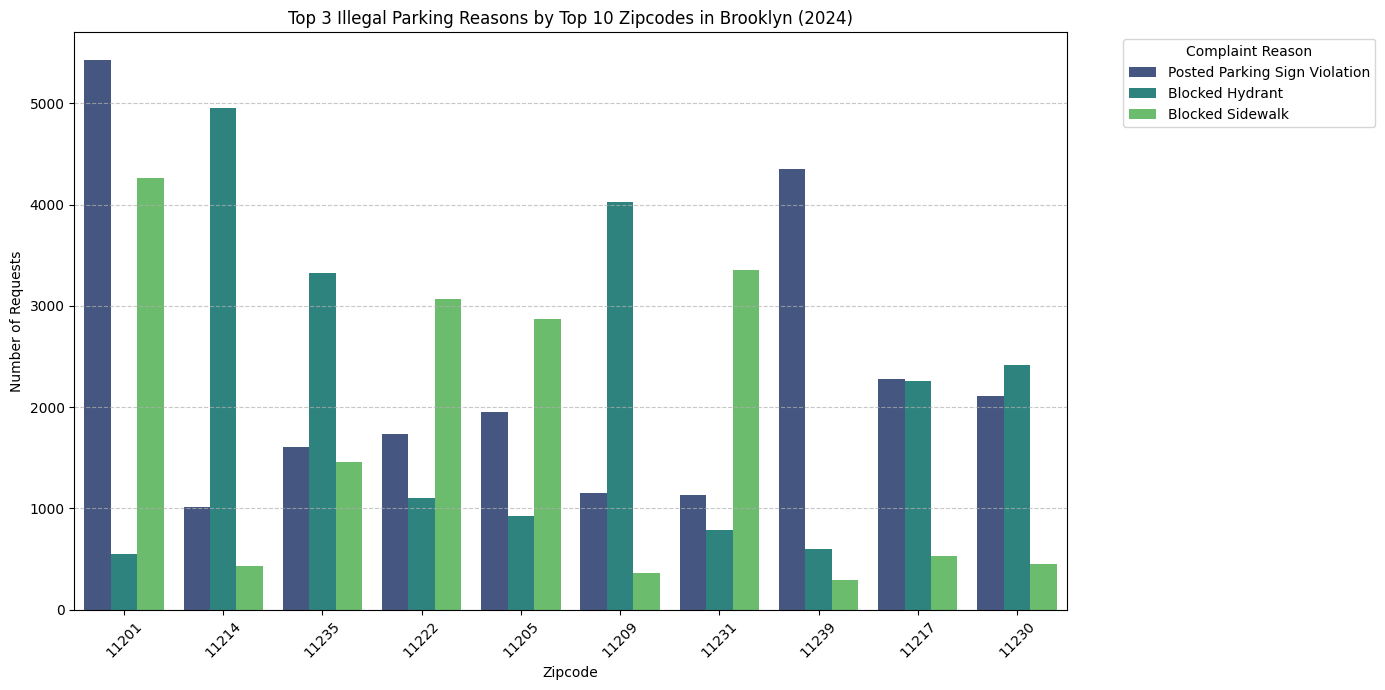

In [ ]:
# Identify the top 10 zipcodes for these specific parking complaints
top_zips = top_parking_df['incident_zip'].value_counts().head(10).index
zip_parking_df = top_parking_df[top_parking_df['incident_zip'].isin(top_zips)]

# Group and plot
plt.figure(figsize=(14, 7))
sns.countplot(data=zip_parking_df, x='incident_zip', hue='descriptor', palette='viridis', order=top_zips)
plt.title('Top 3 Illegal Parking Reasons by Top 10 Zipcodes in Brooklyn (2024)')
plt.xlabel('Zipcode')
plt.ylabel('Number of Requests')
plt.legend(title='Complaint Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Most of these zipcodes show major disparities between the specific complaint reason for illegal parking. Could be related to the infastructure.

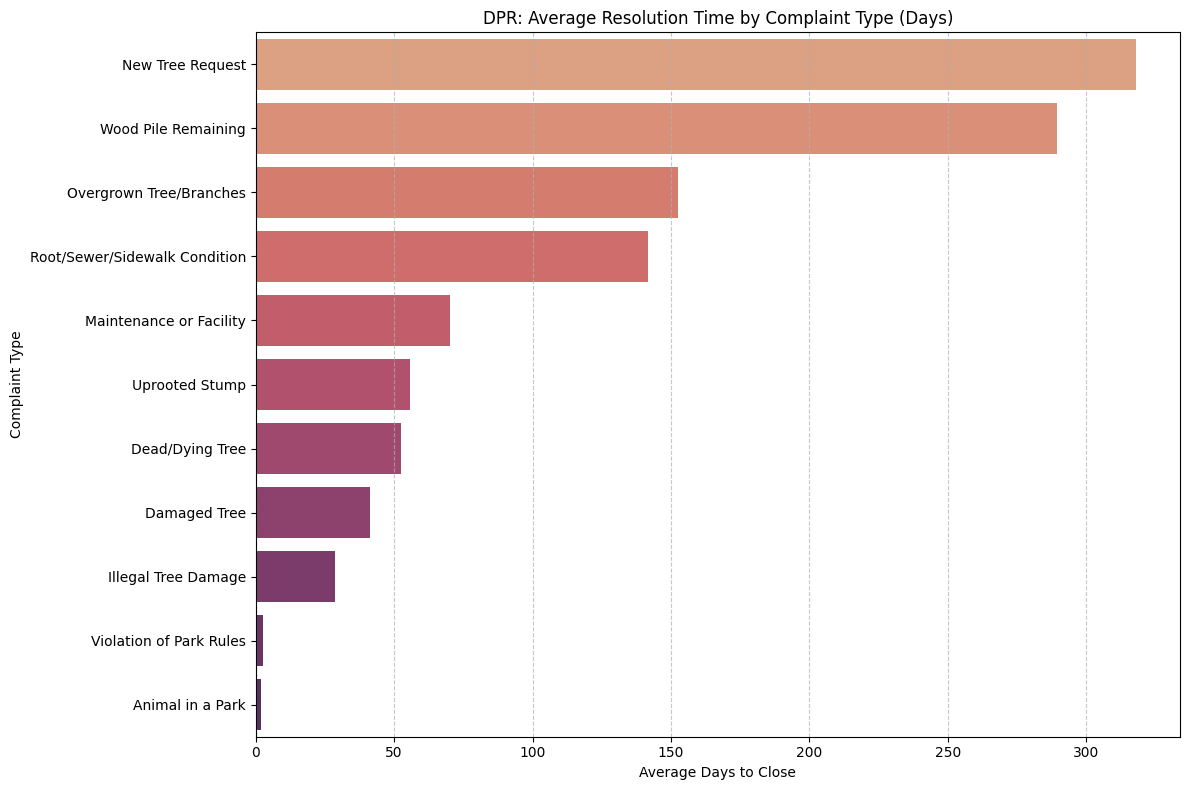

DPR Complaint Analysis (Speed vs. Volume):


,Avg Days,Total Requests
complaint_type,,
New Tree Request,317.926457,7577
Wood Pile Remaining,289.298556,257
Overgrown Tree/Branches,152.539699,7967
Root/Sewer/Sidewalk Condition,141.714864,3463
Maintenance or Facility,70.249978,9191
Uprooted Stump,55.698967,31
Dead/Dying Tree,52.603324,2321
Damaged Tree,41.202355,10405
Illegal Tree Damage,28.582438,1848


In [ ]:
# Filter data for DPR only
dpr_df = df[df['agency'] == 'DPR']

# 1. Average resolution time by Complaint Type for DPR
dpr_complaint_res = dpr_df.groupby('complaint_type')['resolution_days'].mean().sort_values(ascending=False)

# 2. Look at the volume vs speed for DPR complaints
dpr_counts = dpr_df['complaint_type'].value_counts()
dpr_analysis = pd.DataFrame({'Avg Days': dpr_complaint_res, 'Total Requests': dpr_counts})

# Visualization: DPR Resolution Time by Complaint Type
plt.figure(figsize=(12, 8))
sns.barplot(x=dpr_complaint_res.values, y=dpr_complaint_res.index, hue=dpr_complaint_res.index, palette='flare', legend=False)
plt.title('DPR: Average Resolution Time by Complaint Type (Days)')
plt.xlabel('Average Days to Close')
plt.ylabel('Complaint Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display the analysis table for context
print("DPR Complaint Analysis (Speed vs. Volume):")
display(dpr_analysis.sort_values(by='Avg Days', ascending=False))

The Department of Parks and Recreation is mostly slow with new tree and wood pile remaining requests. Tree planting is most likely seasonal and wood piles are probably low priority.

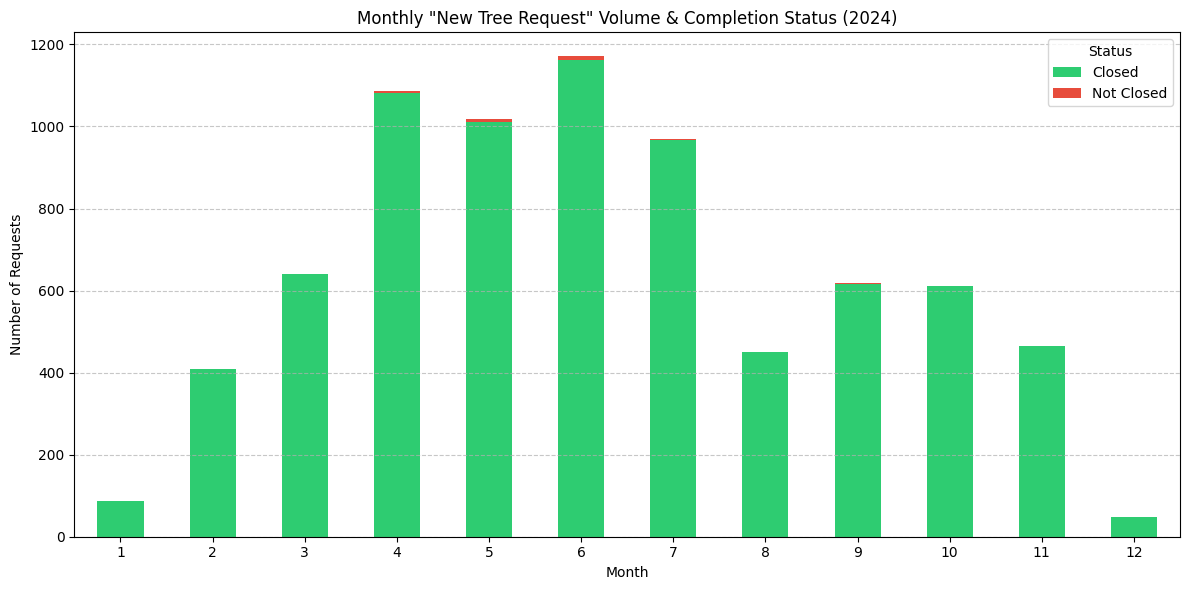

--- Backlog Analysis for New Tree Requests ---
Total Requests: 7577
Number of Open/Pending (Backlog): 27
Backlog Percentage: 0.36%


In [ ]:
# Filter for 'New Tree Request' and relevant columns
ntr_df = df[df['complaint_type'] == 'New Tree Request'].copy()

# Create a simplified status: 'Closed' vs 'Not Closed'
ntr_df['status_group'] = ntr_df['status'].apply(lambda x: 'Closed' if x == 'Closed' else 'Not Closed')

# Group by month and status_group
ntr_monthly = ntr_df.groupby(['month', 'status_group']).size().unstack(fill_value=0)

# Visualization: Monthly Completion Status
plt.figure(figsize=(12, 6))
ntr_monthly.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#2ecc71', '#e74c3c'])
plt.title('Monthly "New Tree Request" Volume & Completion Status (2024)')
plt.xlabel('Month')
plt.ylabel('Number of Requests')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate Backlog
backlog_count = ntr_df[ntr_df['status_group'] == 'Not Closed'].shape[0]
total_requests = ntr_df.shape[0]
backlog_pct = (backlog_count / total_requests) * 100

print(f"--- Backlog Analysis for New Tree Requests ---")
print(f"Total Requests: {total_requests}")
print(f"Number of Open/Pending (Backlog): {backlog_count}")
print(f"Backlog Percentage: {backlog_pct:.2f}%")

This confirms the seasonality of new tree requests and that isn't much of a backlog

In [ ]:
# Display unique values for the agency_name column
unique_agencies = df['agency_name'].unique()
print("Unique Agency Names:")
print(unique_agencies)

Unique Agency Names:
['New York City Police Department'
 'Department of Housing Preservation and Development'
 'Department of Environmental Protection' 'Department of Buildings'
 'Department of Transportation' 'Department of Sanitation'
 'Department of Consumer and Worker Protection'
 'Department of Health and Mental Hygiene'
 'Department of Homeless Services' 'Department of Parks and Recreation'
 'Taxi and Limousine Commission' 'Economic Development Corporation'
 'Department of Education' 'Office of Technology and Innovation']


**SQL Query**

In [ ]:
!pip install pandasql
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

# Query 1: Top descriptors for DOHMH
query_1 = """
SELECT
    agency_name,
    descriptor,
    COUNT(*) as request_count
FROM df
WHERE agency_name IN ('Department of Health and Mental Hygiene')
GROUP BY agency_name, descriptor
ORDER BY request_count DESC
LIMIT 5;
"""
# Query 2: Top descriptors for DOE
query_2 = """
SELECT
    agency_name,
    descriptor,
    COUNT(*) as request_count
FROM df
WHERE agency_name IN ('Department of Education')
GROUP BY agency_name, descriptor
ORDER BY request_count DESC
LIMIT 5;
"""

# Query 3: Which 5 zip codes have the highest volume of complaints?
query_3 = """
SELECT
    incident_zip,
    COUNT(*) as total_complaints
FROM df
WHERE incident_zip IS NOT NULL
GROUP BY incident_zip
ORDER BY total_complaints DESC
LIMIT 5;
"""

# Query 4: Which 5 agencies have the highest volume of complaints?
query_4 = """
SELECT
    agency_name,
    COUNT(*) as total_complaints
FROM df
WHERE agency_name IS NOT NULL
GROUP BY agency_name
ORDER BY total_complaints DESC
LIMIT 5;
"""

print("--- Results: Top Descriptors (DOE & DOHMH) ---")
print(pysqldf(query_1))
print(pysqldf(query_2))

print("\n--- Results: Top 5 Zipcodes and Agencies by Complaint Volume ---")
print(pysqldf(query_3))
print(pysqldf(query_4))

--- Results: Top Descriptors (DOE & DOHMH) ---
                               agency_name                    descriptor  \
0  Department of Health and Mental Hygiene                  Rat Sighting   
1  Department of Health and Mental Hygiene  Condition Attracting Rodents   
2  Department of Health and Mental Hygiene              Signs of Rodents   
3  Department of Health and Mental Hygiene       Rodents/Insects/Garbage   
4  Department of Health and Mental Hygiene    Allowed in Smoke Free Area   

   request_count  
0          10048  
1           2596  
2           1542  
3           1232  
4           1139  
               agency_name                descriptor  request_count
0  Department of Education  Air Conditioning Problem            182
1  Department of Education         Unclean Condition            141
2  Department of Education              Rodents/Mice            140
3  Department of Education    Other School Condition            102
4  Department of Education           Heati

A lot of service requests the DOE and DOHMH deal with relates to cleanliness, rats, and air conditioning/quality. The NYPD deals with the most compliants

Geographic Context:
Zip code 11226 covers the **Flatbush/Ditmas Park** area of Brooklyn. Given its high complaint volume, here are the top complaint types specifically for this zip code.

In [ ]:
# Analyze top complaints for zip code 11226
zips_11226 = df[df['incident_zip'] == '11226']
top_11226 = zips_11226['complaint_type'].value_counts().head(5)

print("Top 5 Complaints in 11226 (Flatbush):")
display(top_11226)

Top 5 Complaints in 11226 (Flatbush):


,count
complaint_type,
HEAT/HOT WATER,7868
Noise - Residential,5923
Illegal Parking,4402
UNSANITARY CONDITION,3813
Noise - Street/Sidewalk,3605


Flatbush mostly receives heat/hot water requests.

In [ ]:
# Filter for NYPD complaints in zipcode 11201
top_11201_nypd = df[(df['agency'] == 'NYPD') & (df['incident_zip'] == '11201')]

# Identify the top 5 descriptors
top_5_descriptors_11201 = top_11201_nypd['descriptor'].value_counts().head(5)

print("Top 5 NYPD Complaint Descriptors for 11201 (Brooklyn Heights/Downtown):")
print(top_5_descriptors_11201)

Top 5 NYPD Complaint Descriptors for 11201 (Brooklyn Heights/Downtown):
descriptor
Posted Parking Sign Violation    5430
Blocked Sidewalk                 4266
Banging/Pounding                 4060
Blocked Bike Lane                2698
Loud Music/Party                 2424
Name: count, dtype: int64


Brooklyn Heights/Downtown receives mostly Posted Parking Sign Violation complaints to NYPD. There probably is a lack of parking space in downtown.

In [ ]:
# Filter for 'Open' status
open_requests = df[df['status'] == 'Open']

# Count open requests per agency
open_counts = open_requests['agency'].value_counts()

# Count total requests per agency
total_counts = df['agency'].value_counts()

# Calculate the ratio (Open / Total)
open_ratio = (open_counts / total_counts).sort_values(ascending=False)

# Create a summary DataFrame for clarity
agency_backlog_summary = pd.DataFrame({
    'Open Requests': open_counts,
    'Total Requests': total_counts,
    'Open Ratio (%)': open_ratio * 100
}).sort_values(by='Open Ratio (%)', ascending=False)

print("Agencies with the highest relative backlog (Open status):")
display(agency_backlog_summary.dropna())

Agencies with the highest relative backlog (Open status):


,Open Requests,Total Requests,Open Ratio (%)
agency,,,
HPD,1448.0,211939,0.683215
DEP,395.0,60525,0.652623
DSNY,81.0,104542,0.077481
TLC,2.0,4812,0.041563


A backlog shows for HPD and DEP.

In [ ]:
import datetime

# Filter for HPD and DEP open requests
backlog_df = df[(df['status'] == 'Open') & (df['agency'].isin(['HPD', 'DEP']))].copy()

# Calculate age of open requests in days
current_date = df['created_date'].max()
backlog_df['age_days'] = (current_date - backlog_df['created_date']).dt.total_seconds() / (24 * 3600)

# Analyze HPD Backlog
print("--- HPD Open Requests Breakdown ---")
hpd_backlog = backlog_df[backlog_df['agency'] == 'HPD']
display(hpd_backlog['complaint_type'].value_counts().head(10))
print(f"Average age of HPD open requests: {hpd_backlog['age_days'].mean():.2f} days")

# Analyze DEP Backlog
print("\n--- DEP Open Requests Breakdown ---")
dep_backlog = backlog_df[backlog_df['agency'] == 'DEP']
display(dep_backlog['complaint_type'].value_counts().head(10))
print(f"Average age of DEP open requests: {dep_backlog['age_days'].mean():.2f} days")

--- HPD Open Requests Breakdown ---


,count
complaint_type,
HEAT/HOT WATER,1279
UNSANITARY CONDITION,37
PLUMBING,35
PAINT/PLASTER,31
GENERAL,20
WATER LEAK,15
DOOR/WINDOW,9
FLOORING/STAIRS,8
ELECTRIC,6


Average age of HPD open requests: 71.73 days

--- DEP Open Requests Breakdown ---


,count
complaint_type,
Sewer,145
Lead,132
Water System,99
Industrial Waste,10
Hazardous Materials,8
Plant,1


Average age of DEP open requests: 119.67 days


A lot of heat/hot water requests remain open most likely since it is highly seasonal (mostly in december)

### **Insight Brief: 2024 Brooklyn 311 Service Trends**

**To:** Brooklyn City Council Representative  

**Overview**  
This brief summarizes an analysis of over one million 311 service requests filed in Brooklyn throughout 2024. The goal was to identify the most pressing quality-of-life issues for residents and evaluate how efficiently city agencies respond to these needs.

**Key Findings**  
1.  **Parking and Noise Dominance:** Illegal Parking is the single most reported issue, occurring twice as often as residential noise. Primary frustrations are blocked sidewalks, parking sign violations, and blocked hydrants, which present significant safety and accessibility concerns.
2.  **Seasonal Infrastructure Strain:** Service requests are heavily influenced by the time of year. Specifically, heating complaints and water system issues see a dramatic surge in December. This suggests that the onset of winter puts a predictable but severe strain on residential infrastructure and utility services.
3.  **Agency Performance Gaps:** There is a wide disparity in response times. While the NYPD resolves most quality-of-life calls in under two hours, the Department of Parks and Recreation averages over 120 days. Much of this delay is tied to "New Tree Requests," which, while seasonal, represent a significant portion of the city's long-term maintenance backlog.

**Recommendation**  
To improve neighborhood safety and agency efficiency, I recommend a **Seasonal Resource Reallocation Strategy**. The city should increase parking enforcement and building inspection staff specifically during the month of December to handle the predictable spikes in hydrant obstructions and heating failures. Proactively addressing these "peak" periods will reduce response times and improve overall resident satisfaction. They can further implement this strategy by increasing staff for certain zipcodes. For example, there are disparities in descriptors by zipcode for illegal parking (ex. 11201 - most parking sign violations, 11214 - most blocked hydrant requests).

**Reflection**

With more time, I would have liked to to analyze service requests within the last few years relating to the Bronx, where The Knowledge House is headquartered. I chose Brooklyn for this project since out of the different dataset boroughs, they are the most similiar demographic-wise. I would especially want to focus on the requests by the DOE, to learn more about the type of learning environment Bronx students experience. I would compared this new analysis to my Brooklyn analysis, and NYC as a whole to create a larger picture, conveying through Tableau.
I would also want to investigate data inconsistencies such as in status and closed_date.

### Technical Summary of Notebook Analysis

This notebook performs an exploratory data analysis (EDA) on the 2024 NYC-Brooklyn 311 service request dataset to uncover patterns, data quality issues, and agency performance metrics. The analysis workflow encompassed data loading, cleaning, transformation, and various analytical queries and visualizations.

#### 1. Data Loading and Initial Inspection:
- The dataset, initially a parquet file, was loaded into a pandas DataFrame.
- Initial shape (`df.shape`) and data types (`df.info()`) were inspected, revealing over 1 million records and 14 columns, including `datetime64[us]` for date columns and `object` for categorical and descriptive fields.

#### 2. Data Cleaning and Preprocessing:
- **`unique_key` Removal**: The `unique_key` column was dropped as it served no analytical purpose beyond being a unique identifier.
- **Negative `response_hours`**: Identified 78 rows where `response_hours` were negative, indicating `closed_date` was earlier than `created_date`. These logically inconsistent records were removed to ensure data integrity. The `status` of these records varied, including 'Pending' and 'Closed', reinforcing the decision to remove them.
- **Non-Brooklyn `incident_zip`**: Detected 8 records with `incident_zip` values not starting with '112', suggesting they did not belong to Brooklyn. These were filtered out to maintain borough-specific focus.
- **`status` and `closed_date` Consistency**:
    - Discovered 569 requests where `closed_date` was present, but `status` was not 'Closed' (e.g., 'Assigned', 'Open'). These `status` values were updated to 'Closed' to reflect the presence of a resolution timestamp.
    - 'Unspecified' statuses (2 records) were updated to 'Open', assuming they were active requests without specific status assignment.
    - Noted 3,946 requests with 'Closed' status but null `closed_date`. These were retained, acknowledging potential manual status updates without corresponding timestamp entries.

#### 3. Exploratory Data Analysis (EDA) and Visualization:
- **Top Complaint Types**: Identified the top 10 most common `complaint_type`s using `value_counts()`. `Illegal Parking` and `Noise - Residential` were significantly dominant. A bar chart visualized these frequencies.
- **Agency Resolution Times**: Calculated `resolution_days` as the difference between `closed_date` and `created_date`. Grouped by `agency` to find average resolution times, identifying `NYPD` as the fastest (avg 0.08 days) and `DPR` (Department of Parks and Recreation) as the slowest (avg 122.45 days). A bar chart illustrated this disparity.
- **Seasonality Analysis**: Extracted `month` from `created_date` and created an interactive Plotly heatmap to visualize monthly trends of the top 10 complaint types. Key observations included:
    - `HEAT/HOT WATER` peaking in winter months (Dec-Jan).
    - `Noise - Street/Sidewalk` concentrated in warmer months.
    - `Illegal Parking` and `Noise - Residential` showing spikes in December, possibly due to winter conditions or holiday activities.
- **Specific Complaint Deep Dive (Illegal Parking)**: Analyzed `Illegal Parking` complaints further by identifying top `descriptor`s (e.g., 'Blocked Hydrant', 'Posted Parking Sign Violation'). Monthly trends for the top 3 descriptors were plotted, reinforcing the December spike. Further, a county plot displayed the distribution of these top 3 reasons across the top 10 zip codes for parking complaints, revealing geographic variations in specific parking issues.
- **DPR Backlog Investigation**: Focused on DPR, the slowest agency. Analyzed resolution times by `complaint_type` within DPR, highlighting 'New Tree Request' and 'Wood Pile Remaining' as particularly slow. A stacked bar chart for 'New Tree Request' volume and completion status by month confirmed seasonality but showed a low overall backlog percentage (0.36%).

#### 4. SQL Queries using `pandasql`:
- Utilized `pandasql` to execute SQL-like queries directly on the DataFrame.
- **Top Descriptors for DOHMH and DOE**: Queried to find the top 5 `descriptor`s for `Department of Health and Mental Hygiene` and `Department of Education`, revealing common issues like 'Rat Sighting' and 'Air Conditioning Problem', respectively.
- **Top Zip Codes and Agencies by Complaint Volume**: Identified the top 5 `incident_zip` codes and `agency_name`s with the highest complaint volumes.
- **Geographic Insights**: Focused on specific zip codes (e.g., `11226` for Flatbush, `11201` for Brooklyn Heights/Downtown) to determine their dominant complaint types and descriptors.

#### 5. Backlog Analysis (Open Requests):
- Calculated the ratio of 'Open' requests to total requests per agency to identify potential backlogs.
- `HPD` and `DEP` showed higher relative backlogs. A detailed breakdown of their open `complaint_type`s and average age of open requests (HPD ~71.73 days, DEP ~119.67 days) was provided, with `HEAT/HOT WATER` being prominent for HPD.

#### Conclusion:
This comprehensive analysis provides actionable insights into the nature, seasonality, geographic distribution, and agency-specific performance related to 311 service requests in Brooklyn. The findings can inform resource allocation strategies and targeted interventions to improve service delivery and resident satisfaction.